# Loan Default Prediction MLOps Project
## Section 1 Setup & Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# MLflow tracking
mlflow.set_tracking_uri('./mlruns')

# Paths
DATA_PATH = 'data/Loan_Data.csv'
MODEL_DIR = 'models/'
os.makedirs(MODEL_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## Section 2 Exploratory Data Analysis

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print()
print(df.dtypes)
print()
df.head()

Shape: (10000, 8)

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object



,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [3]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


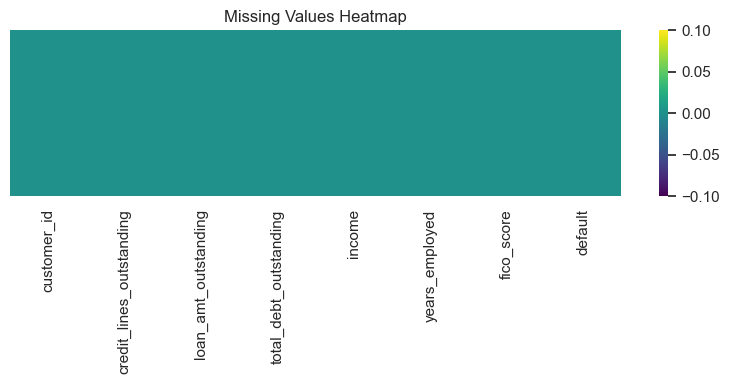

In [4]:
# Null-value heatmap
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

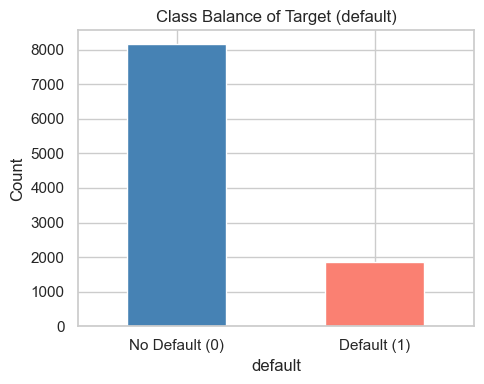

In [5]:
# Class balance
fig, ax = plt.subplots(figsize=(5, 4))
df['default'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Class Balance of Target (default)')
ax.set_xlabel('default')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

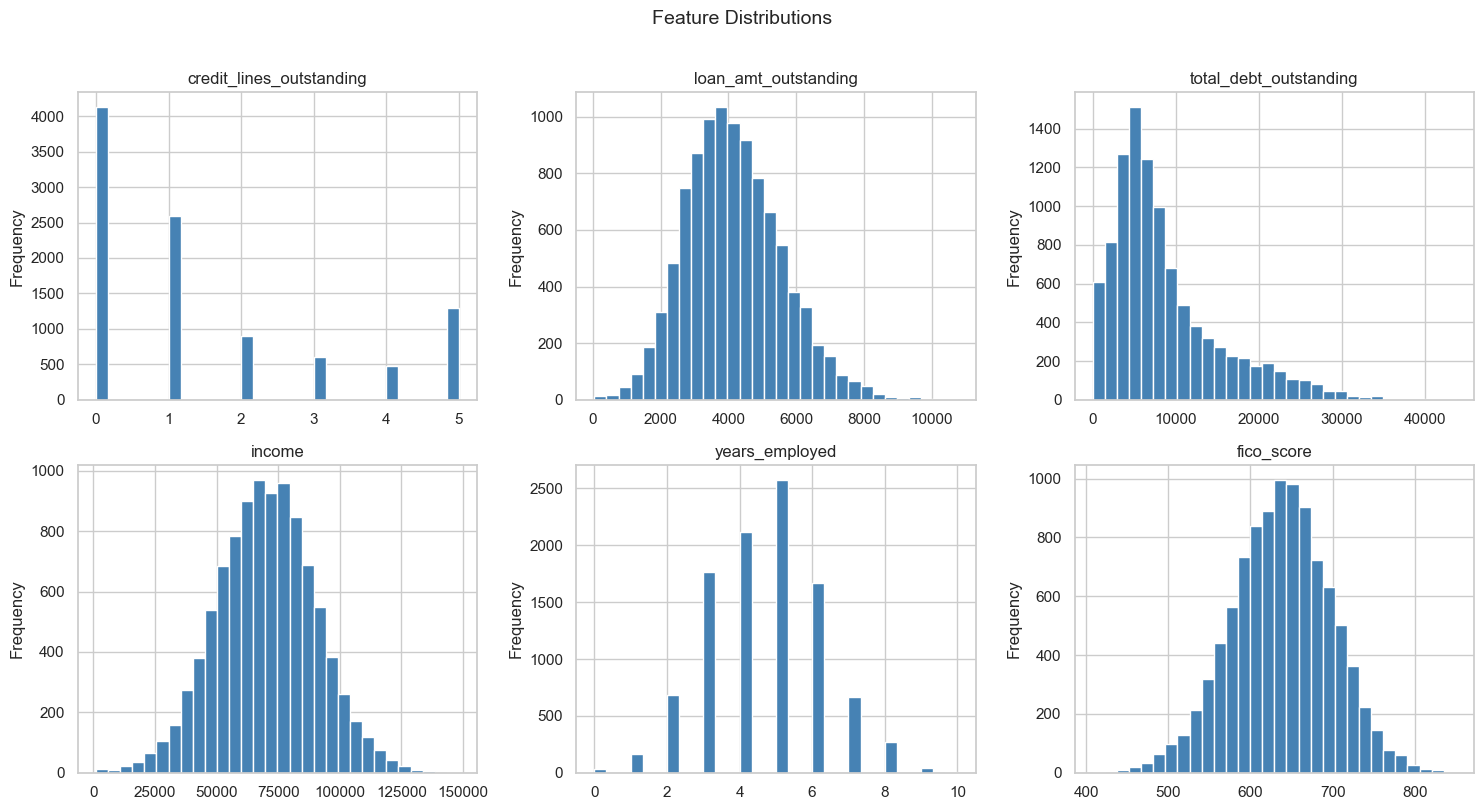

In [6]:
# Feature distributions (2x3 grid)
features = ['credit_lines_outstanding', 'loan_amt_outstanding',
            'total_debt_outstanding', 'income', 'years_employed', 'fico_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(features):
    ax = axes[i // 3, i % 3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Feature Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

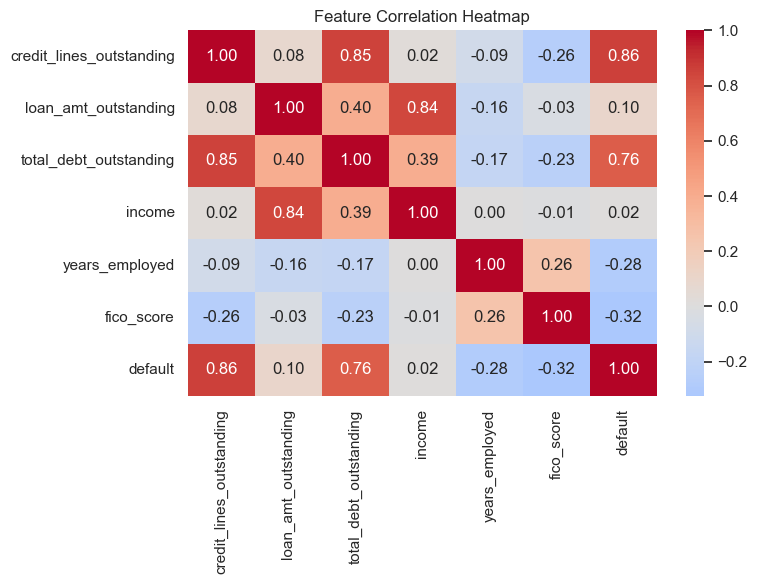

In [7]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.drop(columns=['customer_id']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Section 3 Preprocessing

In [8]:
# Drop customer_id
df = df.drop(columns=['customer_id'])

# Separate features and target
X = df.drop(columns=['default'])
y = df['default']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Save scaler
joblib.dump(scaler, MODEL_DIR + 'scaler.pkl')

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Scaler saved to {MODEL_DIR}scaler.pkl')

Train shape: (8000, 6)
Test shape:  (2000, 6)
Scaler saved to models/scaler.pkl


## Section 4 — Training & MLflow Tracking

### 4a — Logistic Regression

In [9]:
mlflow.set_experiment('logistic_regression')

param_grid_lr = {'C': [0.01, 0.1, 1, 10]}

with mlflow.start_run(run_name='logistic_regression_gridsearch') as parent_run:
    lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    gs_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='roc_auc', refit=True)
    gs_lr.fit(X_train, y_train)

    # Log each CV fold combination as a child run
    for i, params in enumerate(gs_lr.cv_results_['params']):
        with mlflow.start_run(run_name=f'lr_C={params["C"]}', nested=True):
            mlflow.log_params(params)
            mlflow.log_metric('mean_cv_auc', gs_lr.cv_results_['mean_test_score'][i])

    # Evaluate best model on test set
    best_lr = gs_lr.best_estimator_
    y_pred_lr = best_lr.predict(X_test)
    y_proba_lr = best_lr.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_lr)
    auc = roc_auc_score(y_test, y_proba_lr)
    f1 = f1_score(y_test, y_pred_lr)
    prec = precision_score(y_test, y_pred_lr)
    rec = recall_score(y_test, y_pred_lr)

    mlflow.log_param('best_C', gs_lr.best_params_['C'])
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('auc_roc', auc)
    mlflow.log_metric('f1', f1)
    mlflow.log_metric('precision', prec)
    mlflow.log_metric('recall', rec)

    joblib.dump(best_lr, MODEL_DIR + 'logistic_regression.pkl')
    print(f'Logistic Regression — best C={gs_lr.best_params_["C"]}  AUC={auc:.4f}')

Logistic Regression — best C=10  AUC=1.0000


### 4b — Decision Tree

In [10]:
mlflow.set_experiment('decision_tree')

param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'criterion': ['gini', 'entropy']
}

with mlflow.start_run(run_name='decision_tree_gridsearch') as parent_run:
    dt = DecisionTreeClassifier(random_state=42)
    gs_dt = GridSearchCV(dt, param_grid_dt, cv=5, scoring='roc_auc', refit=True)
    gs_dt.fit(X_train, y_train)

    for i, params in enumerate(gs_dt.cv_results_['params']):
        with mlflow.start_run(run_name=f'dt_depth={params["max_depth"]}_crit={params["criterion"]}', nested=True):
            mlflow.log_params(params)
            mlflow.log_metric('mean_cv_auc', gs_dt.cv_results_['mean_test_score'][i])

    best_dt = gs_dt.best_estimator_
    y_pred_dt = best_dt.predict(X_test)
    y_proba_dt = best_dt.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred_dt)
    auc = roc_auc_score(y_test, y_proba_dt)
    f1 = f1_score(y_test, y_pred_dt)
    prec = precision_score(y_test, y_pred_dt)
    rec = recall_score(y_test, y_pred_dt)

    mlflow.log_params(gs_dt.best_params_)
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('auc_roc', auc)
    mlflow.log_metric('f1', f1)
    mlflow.log_metric('precision', prec)
    mlflow.log_metric('recall', rec)

    joblib.dump(best_dt, MODEL_DIR + 'decision_tree.pkl')
    print(f'Decision Tree — best params={gs_dt.best_params_}  AUC={auc:.4f}')

Decision Tree — best params={'criterion': 'entropy', 'max_depth': 3}  AUC=0.9990


### 4c — LightGBM

In [11]:
mlflow.set_experiment('lightgbm')

n_estimators_list = [100, 200]
learning_rate_list = [0.05, 0.1]
num_leaves_list = [31, 63]

best_lgb_auc = 0
best_lgb_model = None
best_lgb_params = {}

for n_est in n_estimators_list:
    for lr_val in learning_rate_list:
        for n_leaves in num_leaves_list:
            with mlflow.start_run(run_name=f'lgb_n{n_est}_lr{lr_val}_lv{n_leaves}'):
                model = lgb.LGBMClassifier(
                    n_estimators=n_est,
                    learning_rate=lr_val,
                    num_leaves=n_leaves,
                    random_state=42,
                    verbosity=-1
                )
                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)
                y_proba = model.predict_proba(X_test)[:, 1]

                acc = accuracy_score(y_test, y_pred)
                auc = roc_auc_score(y_test, y_proba)
                f1 = f1_score(y_test, y_pred)
                prec = precision_score(y_test, y_pred)
                rec = recall_score(y_test, y_pred)

                mlflow.log_param('n_estimators', n_est)
                mlflow.log_param('learning_rate', lr_val)
                mlflow.log_param('num_leaves', n_leaves)
                mlflow.log_metric('accuracy', acc)
                mlflow.log_metric('auc_roc', auc)
                mlflow.log_metric('f1', f1)
                mlflow.log_metric('precision', prec)
                mlflow.log_metric('recall', rec)

                if auc > best_lgb_auc:
                    best_lgb_auc = auc
                    best_lgb_model = model
                    best_lgb_params = {
                        'n_estimators': n_est,
                        'learning_rate': lr_val,
                        'num_leaves': n_leaves
                    }

joblib.dump(best_lgb_model, MODEL_DIR + 'lightgbm.pkl')
print(f'LightGBM — best params={best_lgb_params}  AUC={best_lgb_auc:.4f}')

LightGBM — best params={'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 63}  AUC=0.9999


## Section 5 — Evaluation & Model Selection

In [12]:
# Load all 3 models
model_lr = joblib.load(MODEL_DIR + 'logistic_regression.pkl')
model_dt = joblib.load(MODEL_DIR + 'decision_tree.pkl')
model_lgb = joblib.load(MODEL_DIR + 'lightgbm.pkl')

models = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'LightGBM': model_lgb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,AUC-ROC,F1,Precision,Recall
0,Logistic Regression,0.9990,0.999993,0.997297,0.997297,0.997297
1,Decision Tree,0.9885,0.999014,0.968276,0.988732,0.948649
2,LightGBM,0.9960,0.999949,0.989160,0.991848,0.986486


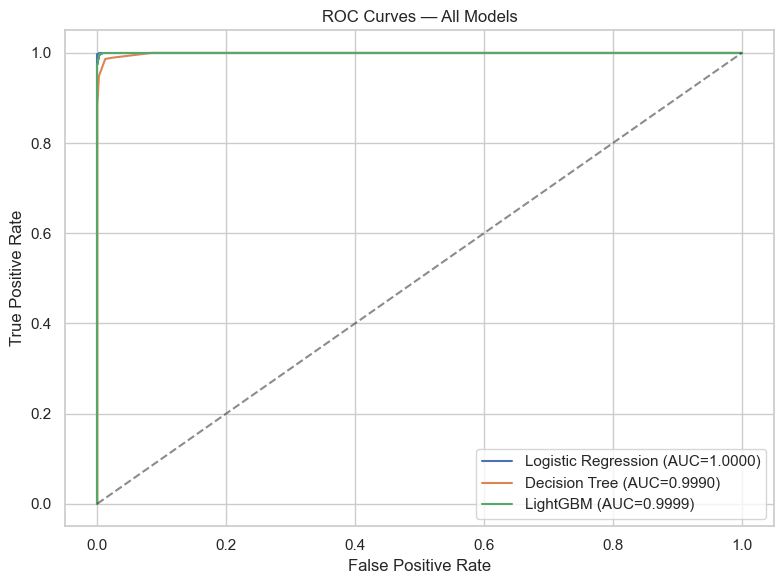

In [13]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

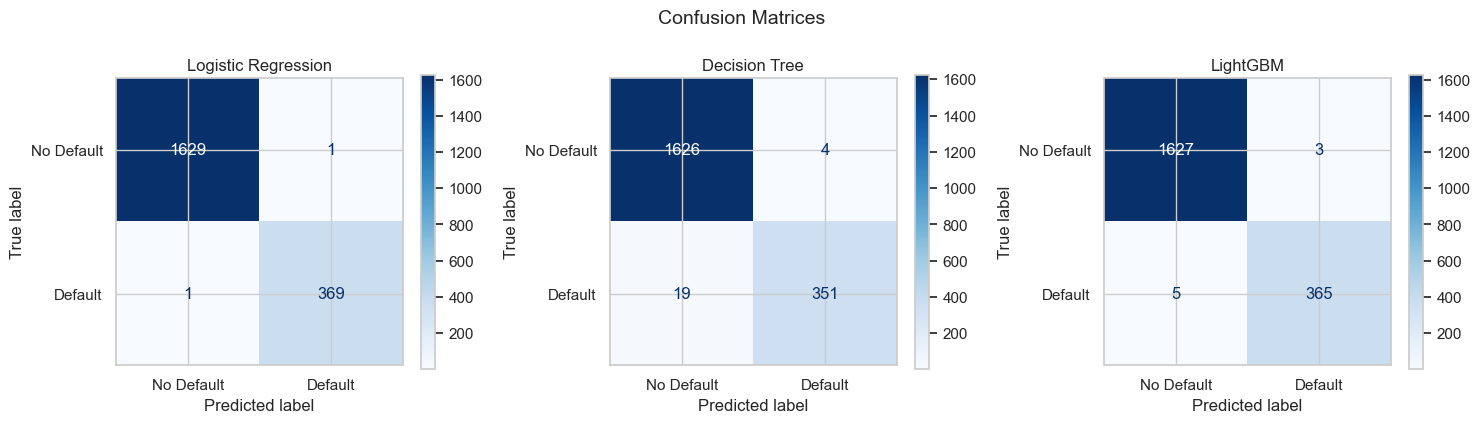

In [14]:
# Confusion matrices (1x3 grid)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default']).plot(ax=ax, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
# Select best model by AUC-ROC
best_row = results_df.loc[results_df['AUC-ROC'].idxmax()]
best_model_name = best_row['Model']
best_auc = best_row['AUC-ROC']

# Map display name to filename
name_to_file = {
    'Logistic Regression': 'logistic_regression',
    'Decision Tree': 'decision_tree',
    'LightGBM': 'lightgbm'
}
best_file = name_to_file[best_model_name]

with open(MODEL_DIR + 'best_model.txt', 'w') as f:
    f.write(best_file)

print(f'Best model: {best_model_name} — AUC-ROC: {best_auc:.4f}')
print(f'Written to {MODEL_DIR}best_model.txt')

Best model: Logistic Regression — AUC-ROC: 1.0000
Written to models/best_model.txt


## Section 6 — Inference Test

In [16]:
# Load best model and scaler
with open(MODEL_DIR + 'best_model.txt', 'r') as f:
    best_name = f.read().strip()

best_model = joblib.load(MODEL_DIR + best_name + '.pkl')
scaler = joblib.load(MODEL_DIR + 'scaler.pkl')

# Example customer
sample = pd.DataFrame([{
    'credit_lines_outstanding': 3,
    'loan_amt_outstanding': 12000,
    'total_debt_outstanding': 25000,
    'income': 65000,
    'years_employed': 8,
    'fico_score': 680
}])

sample_scaled = scaler.transform(sample)
prob = best_model.predict_proba(sample_scaled)[0, 1]
verdict = 'DEFAULT' if prob > 0.5 else 'NO DEFAULT'

print(f'Model: {best_name}')
print(f'Probability of default: {prob:.4f}')
print(f'Verdict: {verdict}')

Model: logistic_regression
Probability of default: 0.0138
Verdict: NO DEFAULT
